<a href="https://colab.research.google.com/github/munozfloresnelsont12-oss/PPIA-github/blob/main/Nelson_Tadeo_Mu%C3%B1oz_Flores_2227010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. INGESTA Y LIMPIEZA CON PANDAS.**

In [48]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#1.Importa el dataset desde la URL oficial.
DATA_URL = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(DATA_URL)
print(df.head())




  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE  


In [49]:
#2.Muestra el conteo de valores nulos por columna y el tipo de dato de cada una.
print(df.isnull().sum())
print(df.info())

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None


In [50]:
#3. Elimina las filas donde falten datos en la columna sex y body_mass_g.
df_cleaned = df.dropna(subset=['sex', 'body_mass_g'])
print(df_cleaned[['sex','body_mass_g']].head())

      sex  body_mass_g
0    MALE       3750.0
1  FEMALE       3800.0
2  FEMALE       3250.0
4  FEMALE       3450.0
5    MALE       3650.0


In [51]:
#4.Sustituye los valores nulos en las columnas bill_length_mm y bill_depth_mm por lamediana de su respectiva columna.
df['bill_length_mm'] = df['bill_length_mm'].fillna(df['bill_length_mm'].mean())
df['bill_depth_mm'] = df['bill_depth_mm'].fillna(df['bill_depth_mm'].mean())
print(df[['bill_length_mm','bill_depth_mm']].head())

   bill_length_mm  bill_depth_mm
0        39.10000       18.70000
1        39.50000       17.40000
2        40.30000       18.00000
3        43.92193       17.15117
4        36.70000       19.30000


In [54]:
#5. Crea una nueva columna llamada bmi_simple calculada como: body_mass_g / flipper_length_mm.
df_cleaned['bmi_simple'] = df_cleaned['body_mass_g'] / df_cleaned['flipper_length_mm']
print(df_cleaned['bmi_simple'].head())

0    20.718232
1    20.430108
2    16.666667
4    17.875648
5    19.210526
Name: bmi_simple, dtype: float64


/tmp/ipykernel_275/456281520.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['bmi_simple'] = df_cleaned['body_mass_g'] / df_cleaned['flipper_length_mm']


**2. ANALISIS ESTADISTICO CON NUMPY**

In [55]:
#1. Convierte las columnas de bill_length_mm y bill_depth_mm en una matriz de NumPy llamada M_picos.
M_picos = df[['bill_length_mm', 'bill_depth_mm']].to_numpy()
print(M_picos)




[[39.1        18.7       ]
 [39.5        17.4       ]
 [40.3        18.        ]
 [43.92192982 17.15116959]
 [36.7        19.3       ]
 [39.3        20.6       ]
 [38.9        17.8       ]
 [39.2        19.6       ]
 [34.1        18.1       ]
 [42.         20.2       ]
 [37.8        17.1       ]
 [37.8        17.3       ]
 [41.1        17.6       ]
 [38.6        21.2       ]
 [34.6        21.1       ]
 [36.6        17.8       ]
 [38.7        19.        ]
 [42.5        20.7       ]
 [34.4        18.4       ]
 [46.         21.5       ]
 [37.8        18.3       ]
 [37.7        18.7       ]
 [35.9        19.2       ]
 [38.2        18.1       ]
 [38.8        17.2       ]
 [35.3        18.9       ]
 [40.6        18.6       ]
 [40.5        17.9       ]
 [37.9        18.6       ]
 [40.5        18.9       ]
 [39.5        16.7       ]
 [37.2        18.1       ]
 [39.5        17.8       ]
 [40.9        18.9       ]
 [36.4        17.        ]
 [39.2        21.1       ]
 [38.8        20.        ]
 

In [56]:
#2. Calcula el valor máximo y mínimo de cada columna usando axis.
print("Valor máximo:", np.max(M_picos, axis=0))
print("Valor mínimo:", np.min(M_picos, axis=0))



Valor máximo: [59.6 21.5]
Valor mínimo: [32.1 13.1]


In [57]:
#3. Calcula el Z-score (normalización) de la matriz M_picos paso a paso (restando la media y dividiendo por la desviación estándar).
media = np.mean(M_picos, axis=0)
desviacion = np.std(M_picos, axis=0)
Z_picos = (M_picos - media) / desviacion

print("Matriz normalizada (Z-score):")
print(Z_picos)

Matriz normalizada (Z-score):
[[-8.87081226e-01  7.87742515e-01]
 [-8.13493989e-01  1.26556330e-01]
 [-6.66319516e-01  4.31719184e-01]
 [-1.30717191e-15  1.80692708e-15]
 [-1.32860464e+00  1.09290537e+00]
 [-8.50287607e-01  1.75409155e+00]
 [-9.23874844e-01  3.29998233e-01]
 [-8.68684416e-01  1.24548680e+00]
 [-1.80692168e+00  4.82579660e-01]
 [-3.53573761e-01  1.55064965e+00]
 [-1.12623974e+00 -2.60250972e-02]
 [-1.12623974e+00  7.56958542e-02]
 [-5.19145043e-01  2.28277281e-01]
 [-9.79065271e-01  2.05925441e+00]
 [-1.71493764e+00  2.00839393e+00]
 [-1.34700145e+00  3.29998233e-01]
 [-9.60668462e-01  9.40323942e-01]
 [-2.61589716e-01  1.80495203e+00]
 [-1.75173125e+00  6.35161087e-01]
 [ 3.82298604e-01  2.21183584e+00]
 [-1.12623974e+00  5.84300612e-01]
 [-1.14463655e+00  7.87742515e-01]
 [-1.47577912e+00  1.04204489e+00]
 [-1.05265251e+00  4.82579660e-01]
 [-9.42271653e-01  2.48353785e-02]
 [-1.58615997e+00  8.89463466e-01]
 [-6.11129089e-01  7.36882039e-01]
 [-6.29525898e-01  3.8085

In [59]:
#4. Crea una máscara booleana para identificar cuántos pingüinos tienen un pico con longitud superior al promedio global. Primero crea la condición a evaluar, después aplícala a la columna correspondiente; finalmente guarda la información de los picos cuyo valor es superior a la longitud promedio global en una nueva variable con nombre df_longer_bills.
promedio_longitud = df['bill_length_mm'].mean()
condicion = df['bill_length_mm'] > promedio_longitud
df_longer_bills = df[condicion]
print("Número de pingüinos con pico mayor al promedio:", len(df_longer_bills))

Número de pingüinos con pico mayor al promedio: 175


**3. COMUNICACION VISUAL CON MATPLOTLIB.**

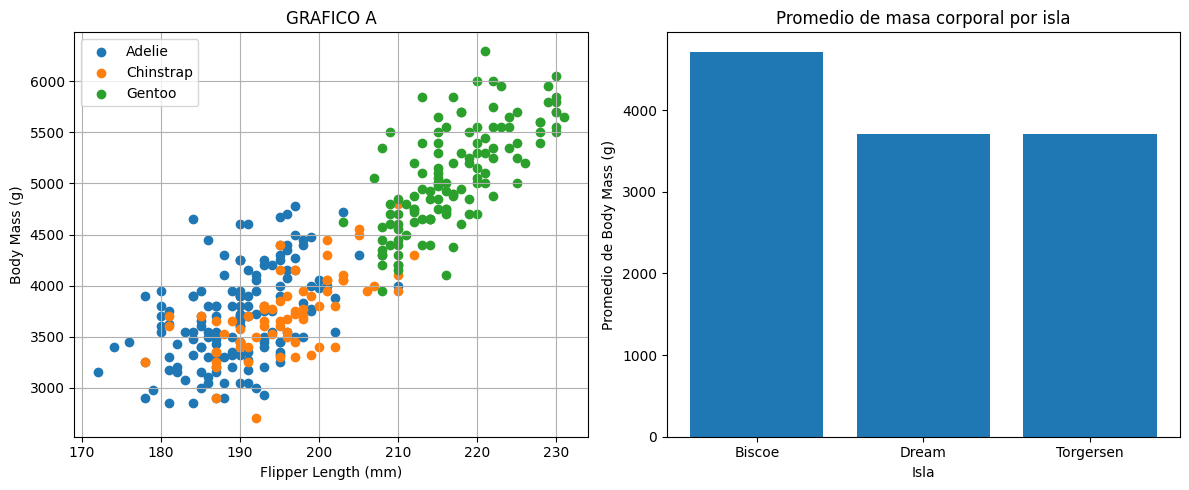

In [70]:
#1. Gráfico A (Scatter Plot): Relación entre flipper_length_mm (X) y body_mass_g (Y). Requisito: Los puntos deben tener un color distinto según la especie. Requisito: Añade una cuadrícula (grid).
fig, ax = plt.subplots(1, 2, figsize=(12,5))

especies = df['species'].unique()

for especie in especies:
    datos = df[df['species'] == especie]
    ax[0].scatter(datos['flipper_length_mm'], datos['body_mass_g'], label=especie)

ax[0].set_xlabel("Flipper Length (mm)")
ax[0].set_ylabel("Body Mass (g)")
ax[0].set_title("GRAFICO A")
ax[0].grid(True)
ax[0].legend()

#2. Gráfico B (Bar Plot): Muestra el promedio de body_mass_g por cada isla. Requisito: El gráfico debe tener etiquetas claras en los ejes y un título descriptivo.
promedio_isla = df.groupby('island')['body_mass_g'].mean()

ax[1].bar(promedio_isla.index, promedio_isla.values)

ax[1].set_xlabel("Isla")
ax[1].set_ylabel("Promedio de Body Mass (g)")
ax[1].set_title("Promedio de masa corporal por isla")

plt.tight_layout()
plt.show()
